# Robust Classification
# Aims to solve the simplicity issue of initial median split.. And provide more business context more applicable results that better fit the target, problem and industry

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

from pathlib import Path
PROJECT = Path('/content/drive/MyDrive/MSC THESIS')
DATA_DIR = PROJECT / 'ml_dataset' / 'data' / 'model_ready' / 'movie_success_v6'
RUN_DIR = DATA_DIR / 'colab_runs_v3'
RUN_DIR.mkdir(parents=True, exist_ok=True)
print('Run dir:', RUN_DIR)

Mounted at /content/drive
Run dir: /content/drive/MyDrive/MSC THESIS/ml_dataset/data/model_ready/movie_success_v6/colab_runs_v3


In [ ]:
import warnings; warnings.filterwarnings('ignore')
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    LeaveOneOut, KFold, StratifiedKFold, GridSearchCV,
    cross_val_predict, train_test_split,
)
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    precision_score, recall_score,
)
from sklearn.utils import shuffle as sk_shuffle

pd.set_option('display.max_columns', 80)
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)
print('Imports OK')

Imports OK


In [ ]:
real_mov  = pd.read_csv(DATA_DIR / 'movie_features_v6.csv')
syn_mov   = pd.read_csv(DATA_DIR / 'movie_features_v6_synthetic.csv')
real_meta = pd.read_csv(DATA_DIR / 'scene_movie_metadata_v6.csv')
syn_meta  = pd.read_csv(DATA_DIR / 'scene_movie_metadata_v6_synthetic.csv')

LEAKAGE = ['budget_usd', 'revenue_usd', 'roi_percent', 'success_class',
           'imdb_rating', 'wom_multiplier', 'wom_multiplier_log']
real_mov = real_mov.drop(columns=LEAKAGE, errors='ignore')
syn_mov  = syn_mov.drop(columns=LEAKAGE, errors='ignore')

META_KEEP = ['movie_id', 'targeted_emotion', 'clip_duration_s',
             'cut_count', 'brightness', 'motion_intensity', 'audio_loudness',
             'silence_ratio', 'music_presence', 'dialogue_density',
             'face_screen_time_ratio', 'lead_screen_time_ratio',
             'release_year', 'genre_primary', 'genre_secondary',
             'country_of_origin', 'budget_categorical',
             'imdb_rating', 'wom_multiplier', 'wom_multiplier_log']
real_meta_sub = real_meta[[c for c in META_KEEP if c in real_meta.columns]]
syn_meta_sub  = syn_meta[[c for c in META_KEEP if c in syn_meta.columns]]
real_mov = real_mov.merge(real_meta_sub, on='movie_id', how='left'); real_mov['is_synthetic'] = 0
syn_mov  = syn_mov.merge(syn_meta_sub, on='movie_id', how='left');  syn_mov['is_synthetic'] = 1
df_all = pd.concat([real_mov, syn_mov], ignore_index=True)

DROP = {'movie_id','condition','n_participants',
        'imdb_rating','wom_multiplier','wom_multiplier_log','is_synthetic'}
df_feat = df_all.copy()
ORD = {'low':1,'moderate':2,'high':3}
for c in ['cut_count','brightness','motion_intensity','audio_loudness',
          'silence_ratio','music_presence','dialogue_density',
          'face_screen_time_ratio','lead_screen_time_ratio','budget_categorical']:
    if c in df_feat.columns: df_feat[c] = df_feat[c].map(ORD)
OH = [c for c in ['targeted_emotion','genre_primary','genre_secondary','country_of_origin']
      if c in df_feat.columns]
df_feat = pd.get_dummies(df_feat, columns=OH, prefix_sep='_', dummy_na=False, dtype=int)

feature_cols = [c for c in df_feat.columns if c not in DROP]
X_all = df_feat[feature_cols].apply(pd.to_numeric, errors='coerce')
y_imdb_all = df_feat['imdb_rating'].astype(float)
y_wom_all  = df_feat['wom_multiplier_log'].astype(float)
synth_mask = df_feat['is_synthetic'].values.astype(bool)
X_all = X_all.drop(columns=X_all.columns[X_all.isna().all()].tolist())
X_all = X_all.drop(columns=X_all.columns[X_all.std()==0].tolist())
feature_cols = list(X_all.columns)

# Composite score
z_imdb = (y_imdb_all - y_imdb_all.mean()) / y_imdb_all.std()
z_wom  = (y_wom_all  - y_wom_all.mean())  / y_wom_all.std()
composite = (z_imdb + z_wom) / 2
print(f'X_all: {X_all.shape}, composite range: [{composite.min():.2f}, {composite.max():.2f}]')

X_all: (50, 360), composite range: [-1.70, 1.89]


# Classifier helpers

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.cross_decomposition import PLSRegression
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
from sklearn.base import BaseEstimator, ClassifierMixin

class PLSDA(BaseEstimator, ClassifierMixin):
    def __init__(self, n_components=2):
        self.n_components = n_components
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.pls = PLSRegression(n_components=self.n_components, scale=False)
        self.pls.fit(X, y.astype(float))
        return self
    def predict_proba(self, X):
        s = np.clip(self.pls.predict(X).flatten(), 0, 1)
        return np.column_stack([1-s, s])
    def predict(self, X):
        return (self.predict_proba(X)[:,1] >= 0.5).astype(int)

def make_enet(C=0.023, l1_ratio=0.1):
    return Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler()),
        ('m',   LogisticRegression(penalty='elasticnet', solver='saga',
                                   C=C, l1_ratio=l1_ratio, class_weight='balanced',
                                   max_iter=10000, random_state=42))])

def make_l2(C=0.001):
    return Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler()),
        ('m',   LogisticRegression(penalty='l2', C=C, class_weight='balanced',
                                   max_iter=10000, random_state=42))])

def make_rf(max_depth=3, max_features=0.3, n_estimators=500):
    return Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('m',   RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth,
                                       max_features=max_features, class_weight='balanced',
                                       random_state=42, n_jobs=-1))])

def make_gbm(learning_rate=0.05, max_iter=200, max_depth=3, l2_regularization=1.0):
    return Pipeline([
        ('m', HistGradientBoostingClassifier(learning_rate=learning_rate,
                                              max_iter=max_iter, max_depth=max_depth,
                                              l2_regularization=l2_regularization,
                                              class_weight='balanced',
                                              random_state=42))])

def make_plsda(n_components=1):
    return Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler()),
        ('m',   PLSDA(n_components=n_components))])

def make_gpc():
    kernel = ConstantKernel(1.0) * RBF(length_scale=1.0, length_scale_bounds=(1e-2,1e3))
    return Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler()),
        ('m',   GaussianProcessClassifier(kernel=kernel, n_restarts_optimizer=10,
                                           random_state=42))])

CLASSIFIERS = {
    'LogReg-ElasticNet': make_enet,
    'LogReg-L2':         make_l2,
    'Random Forest':     make_rf,
    'Gradient Boosting': make_gbm,
    'PLS-DA':            make_plsda,
    'GP Classifier':     make_gpc,
}
print(f'Defined {len(CLASSIFIERS)} classifier factories')

Defined 6 classifier factories


# Permutation test

Question is whether 90% accuracy is reliable or not. Most likely it isn't.

Shuffle labels 200 times, redo the train/test split,
retrain LogReg-ElasticNet (the best of initial classifiers), record accuracy.
Compute p-value as the fraction of permutations with accuracy ≥ real.


Class balance (50/50 split): {1: 25, 0: 25}

Real LogReg-ElasticNet test accuracy: 0.900

Running 200 permutations...
  50/200 done
  100/200 done
  150/200 done
  200/200 done

Permutation accuracies: mean=0.507, std=0.158, max=0.900
Real accuracy: 0.900
p-value (P[perm_acc ≥ real_acc]): 0.0200
  → significant at p<0.05


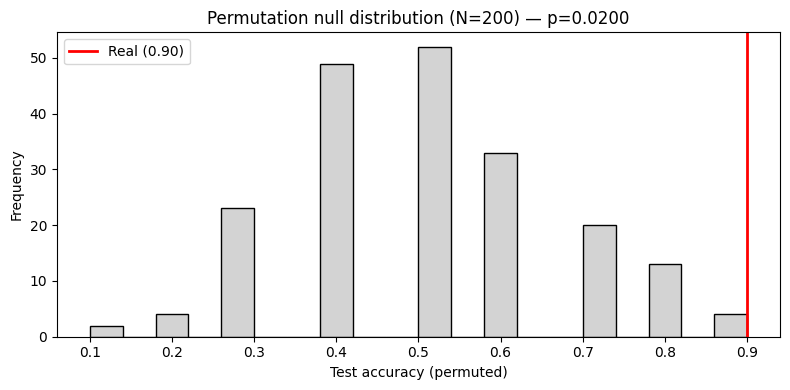

In [ ]:
y_class_50 = (composite >= composite.median()).astype(int)
print(f'Class balance (50/50 split): {y_class_50.value_counts().to_dict()}')

# Real performance
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_class_50, test_size=0.2, random_state=42, stratify=y_class_50)
pipe = make_enet(C=0.023, l1_ratio=0.1)
pipe.fit(X_train, y_train)
real_acc = accuracy_score(y_test, pipe.predict(X_test))
print(f'\nReal LogReg-ElasticNet test accuracy: {real_acc:.3f}')

# Permutation test
N_PERMS = 200
perm_accs = []
print(f'\nRunning {N_PERMS} permutations...')
for i in range(N_PERMS):
    y_perm = sk_shuffle(y_class_50.values, random_state=i)
    Xtr, Xte, ytr, yte = train_test_split(
        X_all, y_perm, test_size=0.2, random_state=42, stratify=y_perm)
    p = make_enet(C=0.023, l1_ratio=0.1)
    p.fit(Xtr, ytr)
    perm_accs.append(accuracy_score(yte, p.predict(Xte)))
    if (i+1) % 50 == 0: print(f'  {i+1}/{N_PERMS} done')

perm_accs = np.array(perm_accs)
p_value = np.mean(perm_accs >= real_acc)
print(f'\nPermutation accuracies: mean={perm_accs.mean():.3f}, '
      f'std={perm_accs.std():.3f}, max={perm_accs.max():.3f}')
print(f'Real accuracy: {real_acc:.3f}')
print(f'p-value (P[perm_acc ≥ real_acc]): {p_value:.4f}')
print('  → significant at p<0.05' if p_value < 0.05 else '  → NOT significant — task may be data-structural')

# Visualise
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(perm_accs, bins=20, color='lightgray', edgecolor='black')
ax.axvline(real_acc, color='red', linewidth=2, label=f'Real ({real_acc:.2f})')
ax.set_xlabel('Test accuracy (permuted)')
ax.set_ylabel('Frequency')
ax.set_title(f'Permutation null distribution (N={N_PERMS}) — p={p_value:.4f}')
ax.legend()
plt.tight_layout(); plt.show()
test_a_results = {'real_acc': float(real_acc),
                  'perm_mean': float(perm_accs.mean()),
                  'perm_std': float(perm_accs.std()),
                  'perm_max': float(perm_accs.max()),
                  'p_value': float(p_value),
                  'n_permutations': int(N_PERMS)}

# Top-25% "hit" classification

Aims to identify outlier successes which are important in terms of business considerations


In [ ]:
hit_threshold = composite.quantile(0.75)
y_hit = (composite >= hit_threshold).astype(int)
print(f'Hit threshold: {hit_threshold:.3f}')
print(f'Class balance: {y_hit.value_counts().to_dict()}  '
      f'(hit fraction: {y_hit.mean():.0%})')

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_hit, test_size=0.2, random_state=42, stratify=y_hit)
print(f'Train: {len(X_train)} ({y_train.value_counts().to_dict()})')
print(f'Test:  {len(X_test)} ({y_test.value_counts().to_dict()})')

baseline_acc = max(y_test.mean(), 1 - y_test.mean())
print(f'\nMajority-class baseline accuracy: {baseline_acc:.3f}  '
      '(predict everything as the dominant class)')

Hit threshold: 0.601
Class balance: {0: 37, 1: 13}  (hit fraction: 26%)
Train: 40 ({0: 30, 1: 10})
Test:  10 ({0: 7, 1: 3})

Majority-class baseline accuracy: 0.700  (predict everything as the dominant class)


In [ ]:
# Run all 6 classifiers, tune the regularisation C / params on training set
def evaluate(pipe, X_tr, y_tr, X_te, y_te):
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)
    try:
        y_proba = pipe.predict_proba(X_te)[:, 1]
    except Exception:
        try:    y_proba = pipe.decision_function(X_te)
        except: y_proba = y_pred.astype(float)
    return {
        'accuracy':  accuracy_score(y_te, y_pred),
        'f1':        f1_score(y_te, y_pred, zero_division=0),
        'precision': precision_score(y_te, y_pred, zero_division=0),
        'recall':    recall_score(y_te, y_pred, zero_division=0),
        'roc_auc':   (roc_auc_score(y_te, y_proba)
                      if len(np.unique(y_te)) > 1 else float('nan')),
    }

test_b_results = {}
for name, factory in CLASSIFIERS.items():
    pipe = factory()
    metrics = evaluate(pipe, X_train, y_train, X_test, y_test)
    test_b_results[name] = metrics
    print(f'  {name:22s}  Acc={metrics["accuracy"]:.2f}  '
          f'F1={metrics["f1"]:.2f}  AUC={metrics["roc_auc"]:.2f}  '
          f'Prec={metrics["precision"]:.2f}  Rec={metrics["recall"]:.2f}')

# Best by ROC-AUC
best_b = max(test_b_results, key=lambda k: test_b_results[k]['roc_auc']
             if not np.isnan(test_b_results[k]['roc_auc']) else -1)
print(f'\nBest classifier (Top-25% hit, by ROC-AUC): {best_b}')
print(f'  → AUC={test_b_results[best_b]["roc_auc"]:.3f}, '
      f'F1={test_b_results[best_b]["f1"]:.3f}, '
      f'Recall={test_b_results[best_b]["recall"]:.3f}')

comparison_b = pd.DataFrame(test_b_results).T.sort_values('roc_auc', ascending=False)
display(comparison_b.round(3))

  LogReg-ElasticNet       Acc=0.80  F1=0.75  AUC=1.00  Prec=0.60  Rec=1.00
  LogReg-L2               Acc=0.70  F1=0.67  AUC=0.95  Prec=0.50  Rec=1.00
  Random Forest           Acc=0.70  F1=0.00  AUC=0.86  Prec=0.00  Rec=0.00
  Gradient Boosting       Acc=0.60  F1=0.50  AUC=0.81  Prec=0.40  Rec=0.67
  PLS-DA                  Acc=0.90  F1=0.86  AUC=0.90  Prec=0.75  Rec=1.00
  GP Classifier           Acc=0.70  F1=0.00  AUC=0.95  Prec=0.00  Rec=0.00

Best classifier (Top-25% hit, by ROC-AUC): LogReg-ElasticNet
  → AUC=1.000, F1=0.750, Recall=1.000


,accuracy,f1,precision,recall,roc_auc
LogReg-ElasticNet,0.8,0.750,0.60,1.000,1.000
LogReg-L2,0.7,0.667,0.50,1.000,0.952
GP Classifier,0.7,0.000,0.00,0.000,0.952
PLS-DA,0.9,0.857,0.75,1.000,0.905
Random Forest,0.7,0.000,0.00,0.000,0.857
Gradient Boosting,0.6,0.500,0.40,0.667,0.810


# Real-only LOO classification

10 real movies, threshold composite at the median of those
10 (5/5 split), leave-one-out cross-validation. Each fold trains on
9 movies, predicts the held-out one. Aggregate predictions across all
10 LOO folds and compute accuracy.


In [ ]:
real_mask = ~synth_mask
X_real = X_all[real_mask].reset_index(drop=True)
composite_real = composite[real_mask].reset_index(drop=True)
real_threshold = composite_real.median()
y_real = (composite_real >= real_threshold).astype(int)
print(f'Real-only threshold (median of 10): {real_threshold:.3f}')
print(f'Class balance: {y_real.value_counts().to_dict()}')

test_c_results = {}
for name, factory in CLASSIFIERS.items():
    pipe = factory()
    y_pred = cross_val_predict(pipe, X_real, y_real, cv=LeaveOneOut(), n_jobs=-1)
    try:
        y_proba = cross_val_predict(pipe, X_real, y_real,
                                    cv=LeaveOneOut(), method='predict_proba',
                                    n_jobs=-1)[:, 1]
    except Exception:
        y_proba = y_pred.astype(float)
    metrics = {
        'accuracy':  accuracy_score(y_real, y_pred),
        'f1':        f1_score(y_real, y_pred, zero_division=0),
        'precision': precision_score(y_real, y_pred, zero_division=0),
        'recall':    recall_score(y_real, y_pred, zero_division=0),
        'roc_auc':   (roc_auc_score(y_real, y_proba)
                      if len(np.unique(y_real)) > 1 else float('nan')),
    }
    test_c_results[name] = metrics
    print(f'  {name:22s}  Acc={metrics["accuracy"]:.2f}  '
          f'F1={metrics["f1"]:.2f}  AUC={metrics["roc_auc"]:.2f}')

print('\nNote: with n=10 LOO, accuracy is in 10% steps. 50% = chance, '
      '70%+ = meaningful signal.')

comparison_c = pd.DataFrame(test_c_results).T.sort_values('roc_auc', ascending=False)
display(comparison_c.round(3))

Real-only threshold (median of 10): 0.338
Class balance: {1: 5, 0: 5}
  LogReg-ElasticNet       Acc=0.60  F1=0.71  AUC=0.68
  LogReg-L2               Acc=0.30  F1=0.22  AUC=0.24
  Random Forest           Acc=0.30  F1=0.22  AUC=0.16
  Gradient Boosting       Acc=0.50  F1=0.00  AUC=0.10
  PLS-DA                  Acc=0.30  F1=0.22  AUC=0.24
  GP Classifier           Acc=0.40  F1=0.00  AUC=0.50

Note: with n=10 LOO, accuracy is in 10% steps. 50% = chance, 70%+ = meaningful signal.


,accuracy,f1,precision,recall,roc_auc
LogReg-ElasticNet,0.6,0.714,0.556,1.0,0.68
GP Classifier,0.4,0.000,0.000,0.0,0.50
LogReg-L2,0.3,0.222,0.250,0.2,0.24
PLS-DA,0.3,0.222,0.250,0.2,0.24
Random Forest,0.3,0.222,0.250,0.2,0.16
Gradient Boosting,0.5,0.000,0.000,0.0,0.10


# Train on synthetic, test on real

In [ ]:
X_syn = X_all[synth_mask].reset_index(drop=True)
y_syn = y_class_50[synth_mask].reset_index(drop=True)
X_real_test = X_all[~synth_mask].reset_index(drop=True)
y_real_test = y_class_50[~synth_mask].reset_index(drop=True)
print(f'Train (synthetic): {len(X_syn)}, class balance: {y_syn.value_counts().to_dict()}')
print(f'Test  (real):      {len(X_real_test)}, class balance: {y_real_test.value_counts().to_dict()}')

test_d_results = {}
for name, factory in CLASSIFIERS.items():
    pipe = factory()
    pipe.fit(X_syn, y_syn)
    y_pred = pipe.predict(X_real_test)
    try:    y_proba = pipe.predict_proba(X_real_test)[:, 1]
    except Exception:
        try:    y_proba = pipe.decision_function(X_real_test)
        except: y_proba = y_pred.astype(float)
    metrics = {
        'accuracy':  accuracy_score(y_real_test, y_pred),
        'f1':        f1_score(y_real_test, y_pred, zero_division=0),
        'precision': precision_score(y_real_test, y_pred, zero_division=0),
        'recall':    recall_score(y_real_test, y_pred, zero_division=0),
        'roc_auc':   (roc_auc_score(y_real_test, y_proba)
                      if len(np.unique(y_real_test)) > 1 else float('nan')),
    }
    test_d_results[name] = metrics
    print(f'  {name:22s}  Acc={metrics["accuracy"]:.2f}  '
          f'F1={metrics["f1"]:.2f}  AUC={metrics["roc_auc"]:.2f}')

comparison_d = pd.DataFrame(test_d_results).T.sort_values('roc_auc', ascending=False)
display(comparison_d.round(3))

Train (synthetic): 40, class balance: {0: 21, 1: 19}
Test  (real):      10, class balance: {1: 6, 0: 4}
  LogReg-ElasticNet       Acc=0.60  F1=0.60  AUC=0.62
  LogReg-L2               Acc=0.70  F1=0.73  AUC=0.71
  Random Forest           Acc=0.60  F1=0.50  AUC=0.54
  Gradient Boosting       Acc=0.60  F1=0.50  AUC=0.88
  PLS-DA                  Acc=0.80  F1=0.80  AUC=0.73
  GP Classifier           Acc=0.60  F1=0.67  AUC=0.71


,accuracy,f1,precision,recall,roc_auc
Gradient Boosting,0.6,0.500,1.000,0.333,0.875
PLS-DA,0.8,0.800,1.000,0.667,0.729
GP Classifier,0.6,0.667,0.667,0.667,0.708
LogReg-L2,0.7,0.727,0.800,0.667,0.708
LogReg-ElasticNet,0.6,0.600,0.750,0.500,0.625
Random Forest,0.6,0.500,1.000,0.333,0.542


In [ ]:
out = {
    'task': 'robust_classification_sanity_tests',
    'feature_count': len(feature_cols),
    'test_a_permutation': test_a_results,
    'test_b_top25_hit':   test_b_results,
    'test_c_real_only_loo': test_c_results,
    'test_d_synthetic_train_real_test': test_d_results,
    'best_per_test': {
        'A_permutation_p_value': test_a_results['p_value'],
        'B_top25_best': max(test_b_results,
                            key=lambda k: test_b_results[k].get('roc_auc', 0)
                                          if not np.isnan(test_b_results[k].get('roc_auc', np.nan)) else -1),
        'C_real_only_best': max(test_c_results,
                                key=lambda k: test_c_results[k]['accuracy']),
        'D_synth_to_real_best': max(test_d_results,
                                    key=lambda k: test_d_results[k]['accuracy']),
    },
}
out_path = RUN_DIR / 'results_robust_classification.json'
with open(out_path, 'w') as f: json.dump(out, f, indent=2, default=str)
print(f'Saved → {out_path}')

Saved → /content/drive/MyDrive/MSC THESIS/ml_dataset/data/model_ready/movie_success_v6/colab_runs_v3/results_robust_classification.json
